In [1]:
from src.utils.config import DATASET_FINAL, RAW_DIR

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import librosa
import librosa.display

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import umap

from tqdm import tqdm
import torch.nn as nn
from matplotlib.animation import FuncAnimation
from sklearn.utils import resample

c:\Users\nata1\Desktop\4geeks\Sistema de alerta\proyecto4geeks\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sns.set_theme(style="whitegrid")
def pastel_colors(n):
    return sns.color_palette("pastel", n)

plt.rcParams["figure.figsize"] = (12,6)

In [3]:
data = pd.read_csv(DATASET_FINAL)

In [4]:
print("Total audios:", len(data))

Total audios: 71114


In [5]:
eda = data.copy()

In [6]:
eda.shape

(71114, 20)

In [7]:
eda.head()

,audio,label,labels,human_label,human_labels,path,dataset_source,split,env,alertable,emergency,file_exists,audio_format,duration,sample_rate,channels,bit_depth,bit_velocity,size,date_modification
0,--PJHxphWEs.wav,gun_shot,['gun_shot'],gun_shot,['gun_shot'],sonidos\gunshot\--PJHxphWEs.wav,audioset,train,indefinida,True,True,True,wav,10.008,44100.0,Stereo,16.0,1411200.0,1724.11,2026-05-12 17:56:50
1,--aE2O5G5WE.wav,gun_shot,['gun_shot'],gun_shot,['gun_shot'],sonidos\gunshot\--aE2O5G5WE.wav,audioset,train,indefinida,True,True,True,wav,10.008,44100.0,Stereo,16.0,1411200.0,1724.08,2026-05-12 12:27:49
2,-0DLPzsiXXE.wav,ambient_noise,['ambient_noise'],ambient_noise,['ambient_noise'],sonidos\music\-0DLPzsiXXE.wav,audioset,train,indefinida,False,False,True,wav,19.994,48000.0,Stereo,16.0,1536000.0,3748.86,2026-05-12 17:57:08
3,-0SdAVK79lg.wav,ambient_noise,['ambient_noise'],ambient_noise,['ambient_noise'],sonidos\music\-0SdAVK79lg.wav,audioset,train,indefinida,False,False,True,wav,19.994,48000.0,Stereo,16.0,1536000.0,3748.86,2026-05-12 12:36:58
4,-11LhdJgBb8.wav,ambient_noise,['ambient_noise'],ambient_noise,['ambient_noise'],sonidos\music\-11LhdJgBb8.wav,audioset,train,indefinida,False,False,True,wav,19.994,48000.0,Stereo,16.0,1536000.0,3748.86,2026-05-12 17:57:22


In [8]:
eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71114 entries, 0 to 71113
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   audio              71114 non-null  object 
 1   label              71114 non-null  object 
 2   labels             62022 non-null  object 
 3   human_label        71114 non-null  object 
 4   human_labels       62022 non-null  object 
 5   path               71114 non-null  object 
 6   dataset_source     71114 non-null  object 
 7   split              71114 non-null  object 
 8   env                71114 non-null  object 
 9   alertable          71114 non-null  bool   
 10  emergency          71114 non-null  bool   
 11  file_exists        71114 non-null  bool   
 12  audio_format       71113 non-null  object 
 13  duration           71113 non-null  float64
 14  sample_rate        71113 non-null  float64
 15  channels           71113 non-null  object 
 16  bit_depth          711

In [9]:
eda.describe(include="all")

,audio,label,labels,human_label,human_labels,path,dataset_source,split,env,alertable,emergency,file_exists,audio_format,duration,sample_rate,channels,bit_depth,bit_velocity,size,date_modification
count,71114,71114,62022,71114,62022,71114,71114,71114,71114,71114,71114,71114,71113,71113.000000,71113.000000,71113,71104.000000,7.110400e+04,71113.000000,71113
unique,71101,208,3264,22,1050,71114,6,2,4,2,2,1,1,NaN,NaN,3,NaN,NaN,NaN,1169
top,-T-ZI1MZ44g.wav,/C/gun_shot_2778111f,"[""/C/gun_shot_2778111f""]",instrument,"[""instrument"", ""ambient_noise""]",sonidos\gunshot\--PJHxphWEs.wav,zenodo,train,indefinida,False,False,True,wav,NaN,NaN,Mono,NaN,NaN,NaN,2020-06-16 00:54:28
freq,2,4295,4295,14283,13906,1,51197,56926,43638,44291,62620,71114,71113,NaN,NaN,62139,NaN,NaN,NaN,837
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.241172,44675.962806,NaN,16.342934,8.512647e+05,603.239016,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.383070,5558.819574,NaN,1.734229,5.022191e+05,736.090565,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.050000,8000.000000,NaN,8.000000,8.820000e+04,5.980000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.640000,44100.000000,NaN,16.000000,7.056000e+05,146.040000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,44100.000000,NaN,16.000000,7.056000e+05,375.440000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.988000,44100.000000,NaN,16.000000,7.056000e+05,780.170000,NaN


<Axes: xlabel='dataset_source'>

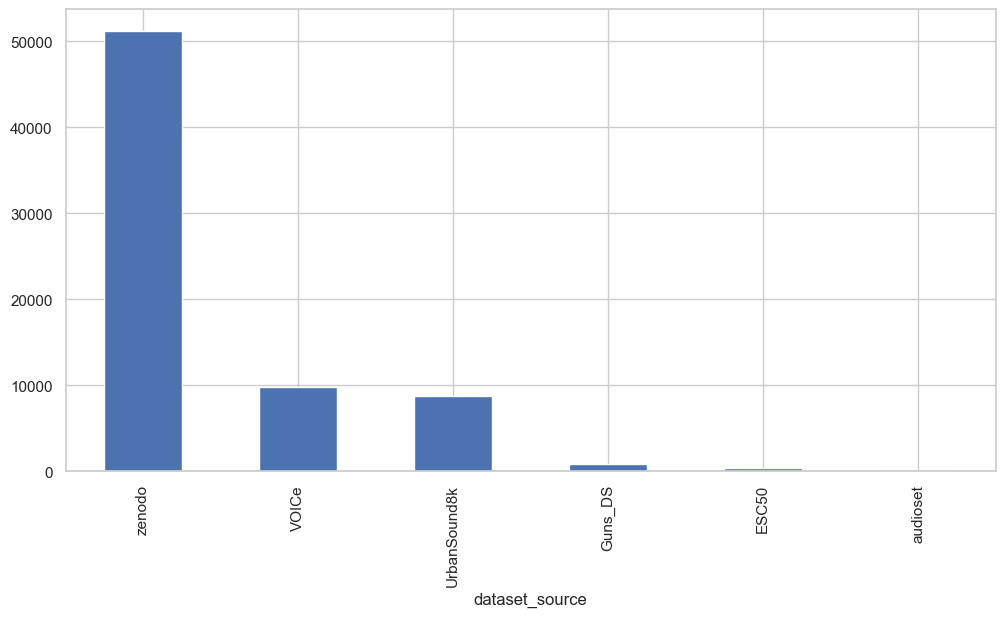

In [10]:
eda["dataset_source"].value_counts().plot(kind="bar")

El dataset final corresponde a una integración multifuente de datos acústicos provenientes de diferentes repositorios públicos.

Se identifican diferencias estructurales entre datasets en cuanto a metadata disponible, duración de audio y esquema de etiquetado, lo cual introduce heterogeneidad que debe considerarse durante el modelado.

In [11]:
eda.isna().sum().sort_values(ascending=False)

labels               9092
human_labels         9092
bit_velocity           10
bit_depth              10
date_modification       1
size                    1
channels                1
sample_rate             1
duration                1
audio_format            1
file_exists             0
audio                   0
label                   0
alertable               0
env                     0
split                   0
dataset_source          0
path                    0
human_label             0
emergency               0
dtype: int64

<Axes: >

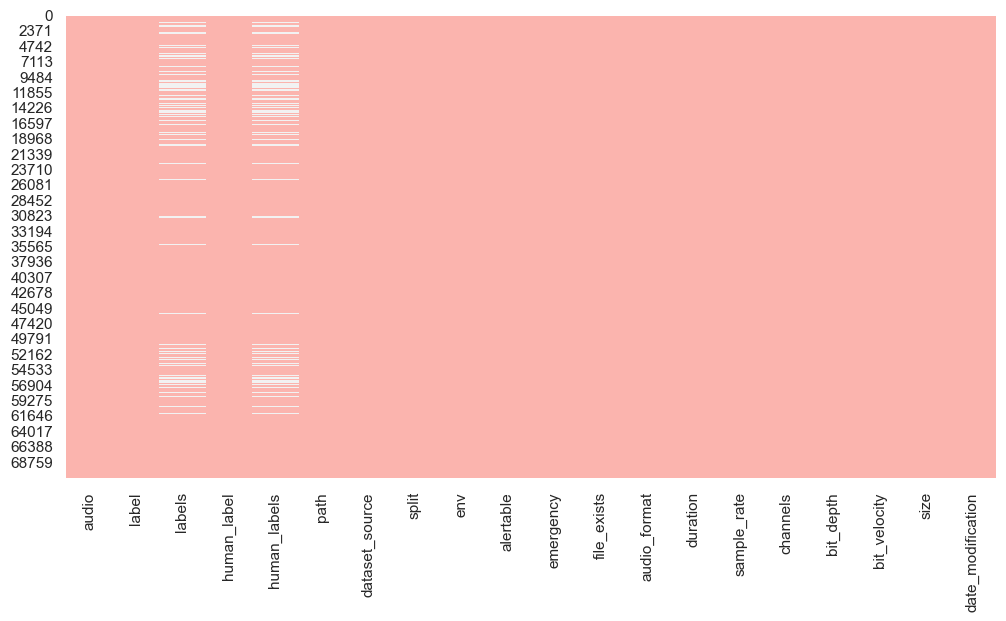

In [12]:
sns.heatmap(eda.isna(), cmap="Pastel1", cbar=False)

Se observa presencia de valores faltantes principalmente en variables de anotación humana, indicando diferencias en el proceso de etiquetado entre datasets origen. Las variables técnicas del audio presentan mayor completitud, permitiendo análisis acústicos consistentes.

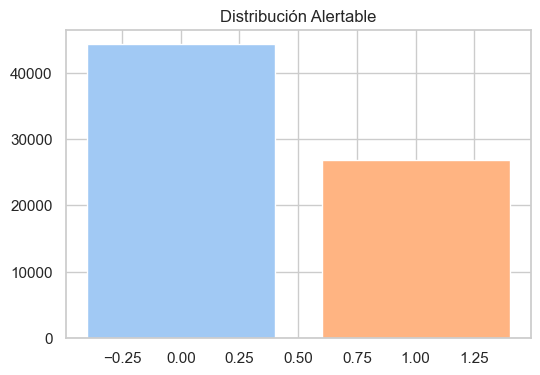

In [13]:
counts = eda["alertable"].value_counts()

plt.figure(figsize=(6,4))

plt.bar(
    counts.index,
    counts.values,
    color=pastel_colors(len(counts))
)

plt.title("Distribución Alertable")
plt.show()

La variable objetivo alertable permite reformular el problema como una tarea de clasificación funcional basada en relevancia operativa del sonido, reduciendo el sesgo generado por clases extremadamente desbalanceadas presentes en la etiqueta emergency.

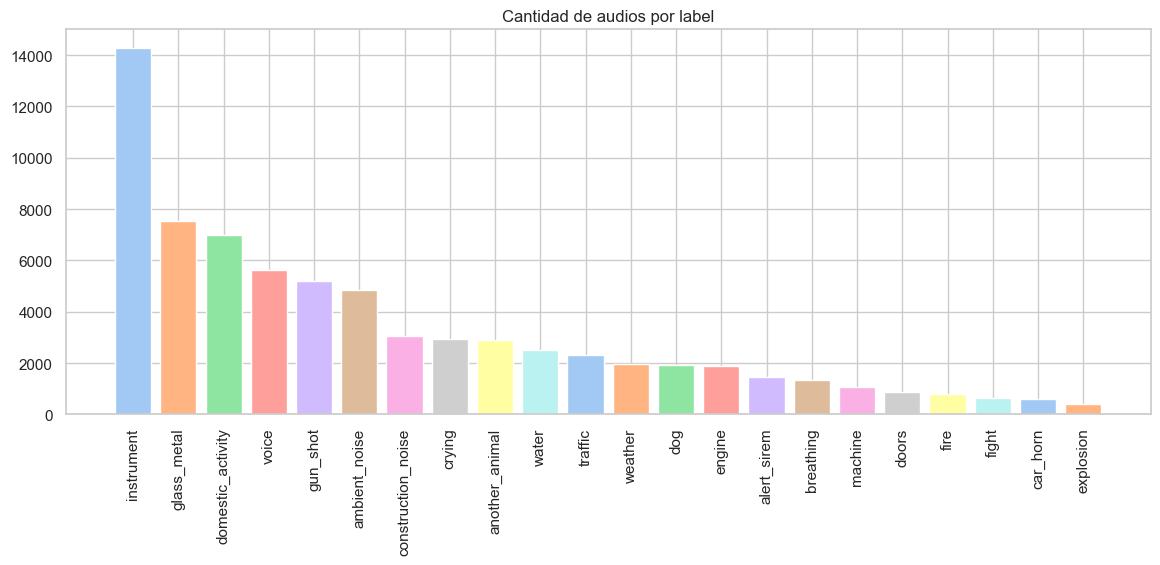

In [14]:
label_counts = eda["human_label"].value_counts()

plt.figure(figsize=(14,5))

plt.bar(
    label_counts.index,
    label_counts.values,
    color=pastel_colors(len(label_counts))
)

plt.xticks(rotation=90)
plt.title("Cantidad de audios por label")

plt.show()

In [15]:
eda.groupby("human_label")["alertable"].mean()

human_label
alert_sirem           1.0
ambient_noise         0.0
another_animal        0.0
breathing             0.0
car_horn              1.0
construction_noise    1.0
crying                1.0
dog                   1.0
domestic_activity     0.0
doors                 0.0
engine                0.0
explosion             1.0
fight                 1.0
fire                  1.0
glass_metal           1.0
gun_shot              1.0
instrument            0.0
machine               0.0
traffic               1.0
voice                 0.0
water                 0.0
weather               0.0
Name: alertable, dtype: float64

Se evidencia desbalance severo entre clases acústicas, lo cual puede inducir sesgo hacia clases dominantes. Será necesario aplicar técnicas como:

- class weighting
- focal loss
- oversampling

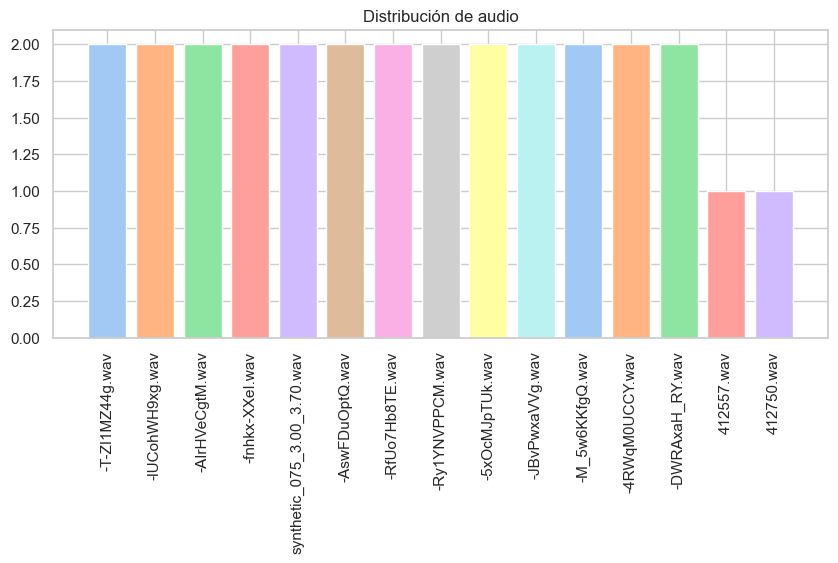

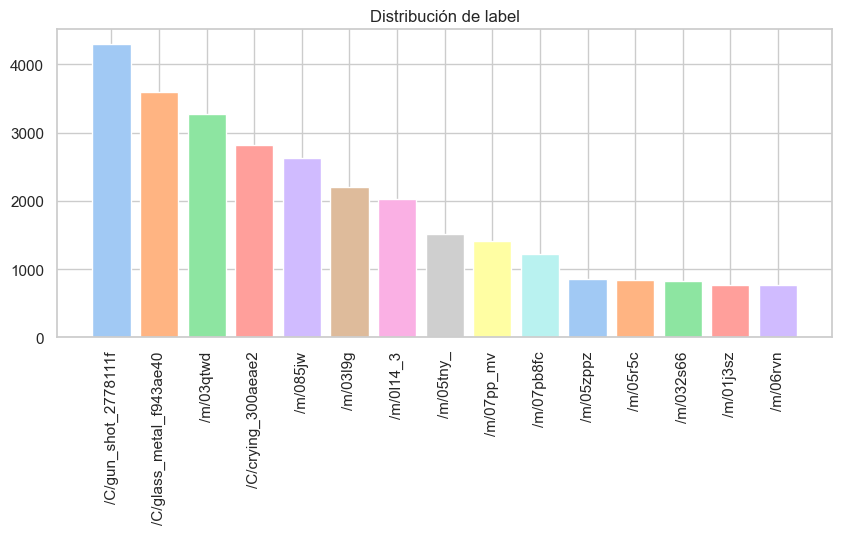

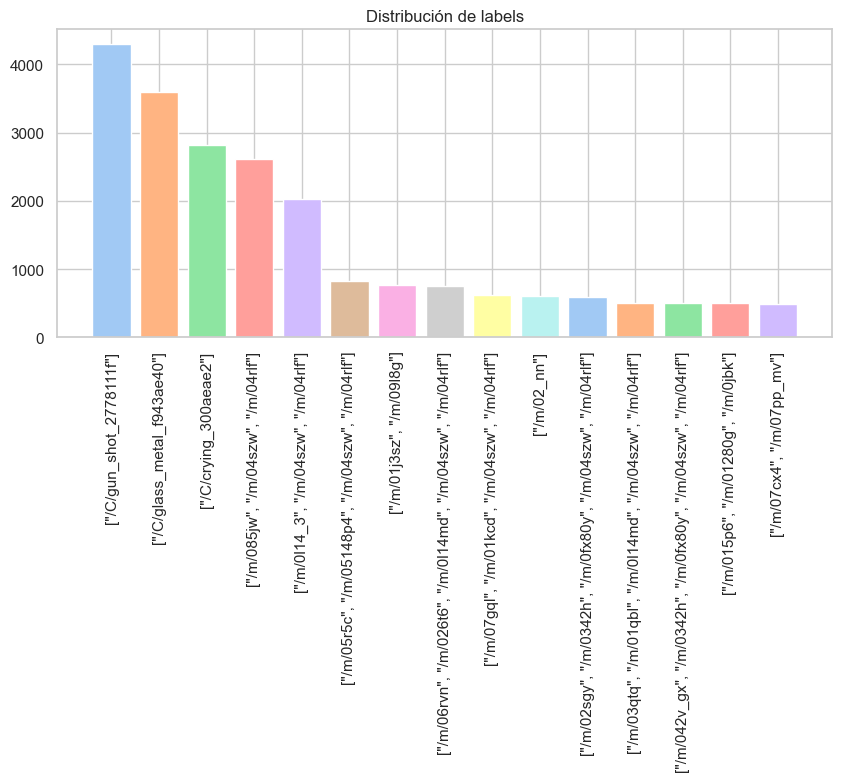

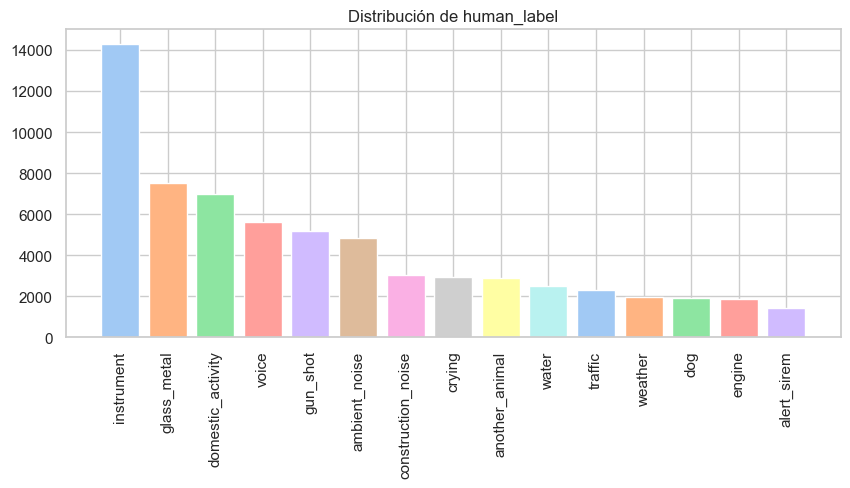

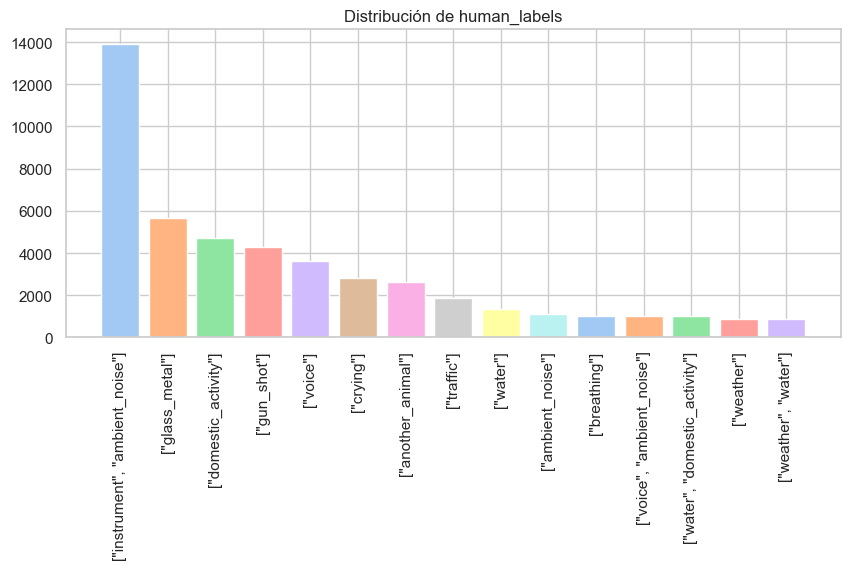

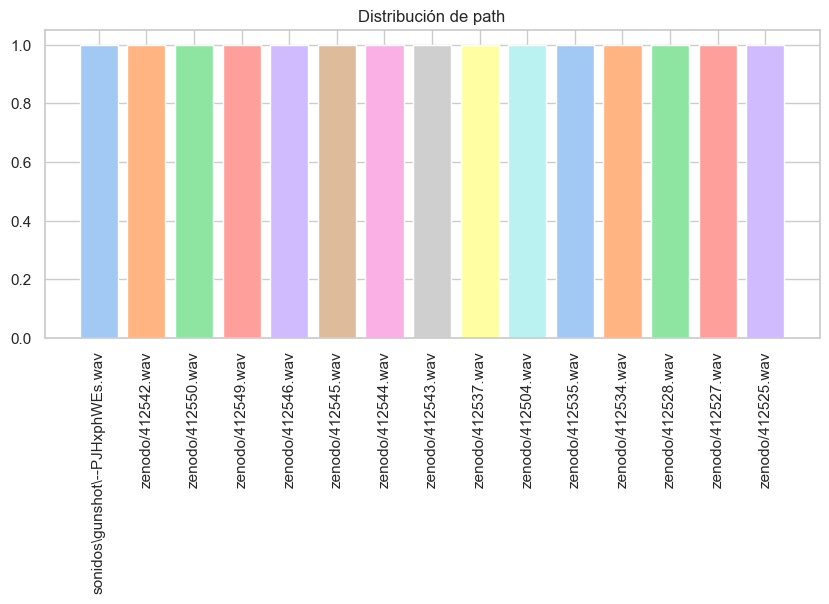

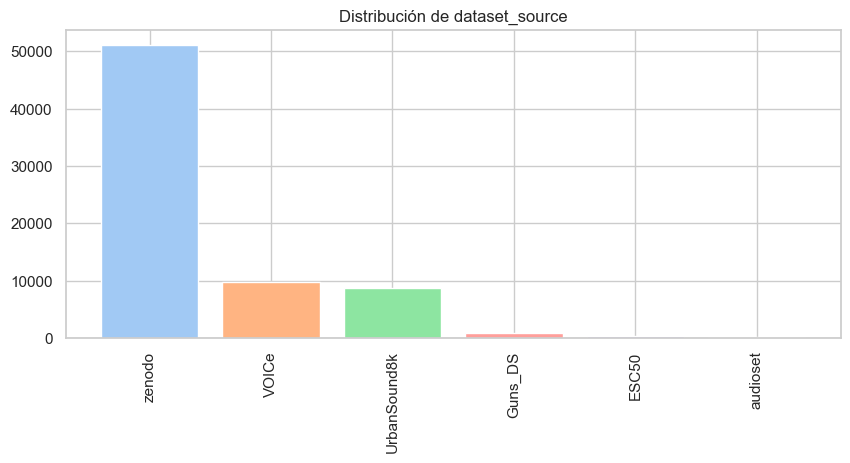

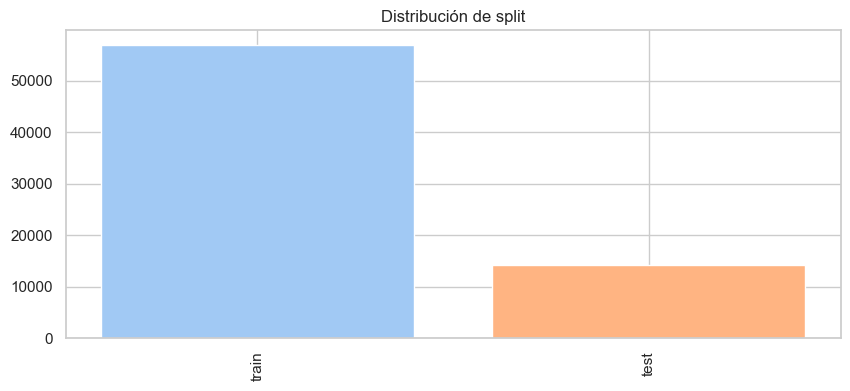

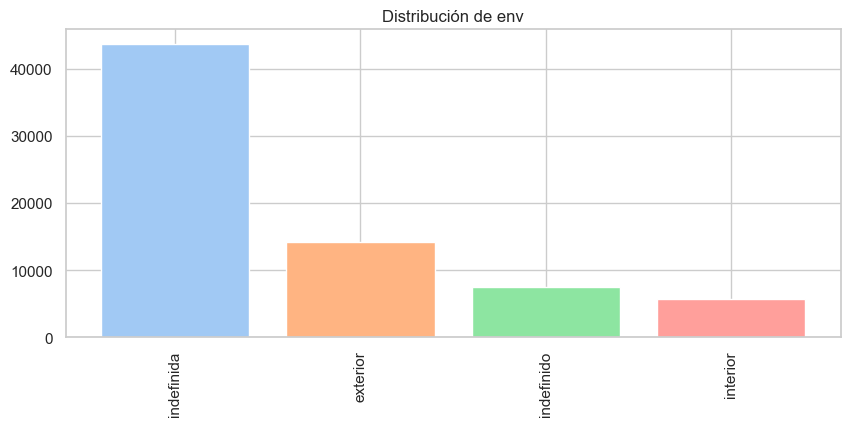

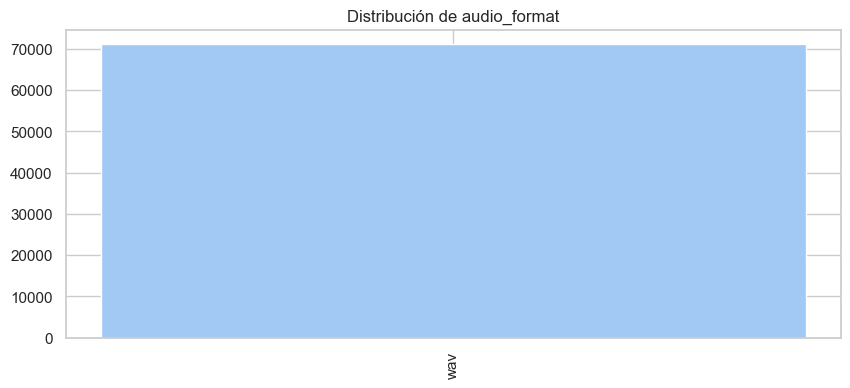

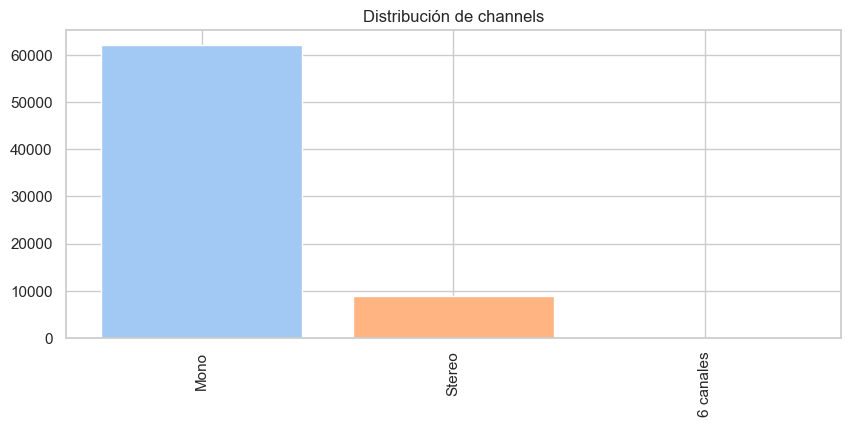

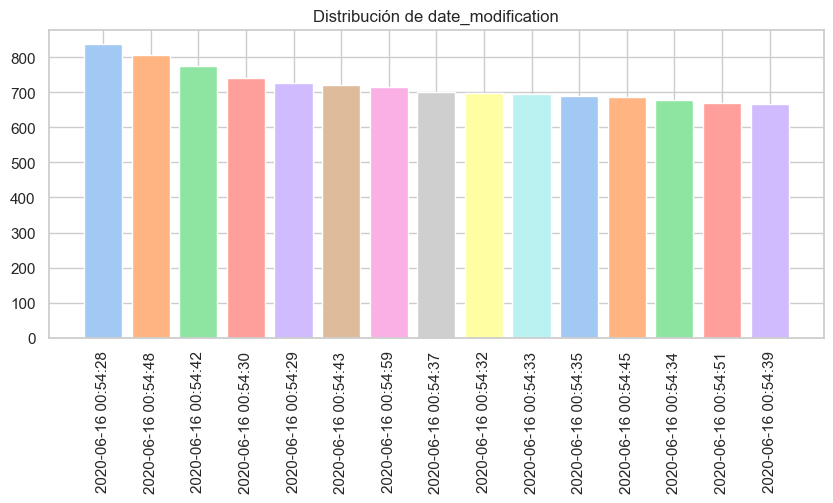

In [16]:
cat_cols = eda.select_dtypes(include="object").columns

for col in cat_cols:

    counts = eda[col].value_counts().head(15)

    plt.figure(figsize=(10,4))

    plt.bar(
        counts.index,
        counts.values,
        color=pastel_colors(len(counts))
    )

    plt.title(f"Distribución de {col}")
    plt.xticks(rotation=90)

    plt.show()

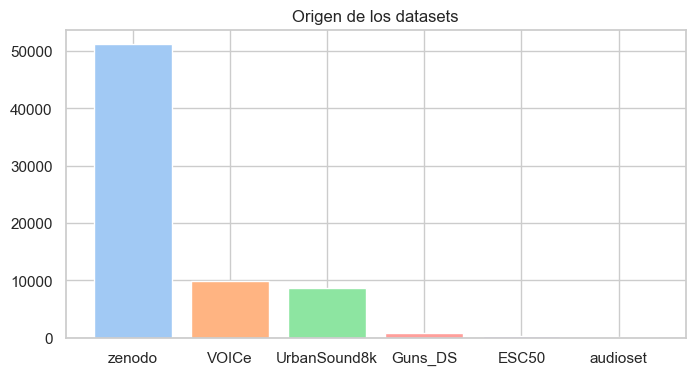

In [17]:
source_counts = eda["dataset_source"].value_counts()

plt.figure(figsize=(8,4))

plt.bar(
    source_counts.index,
    source_counts.values,
    color=pastel_colors(len(source_counts))
)

plt.title("Origen de los datasets")

plt.show()

El análisis por fuente de dataset revela especialización acústica entre repositorios, contribuyendo a diversidad semántica del conjunto final y favoreciendo la capacidad de generalización del modelo.

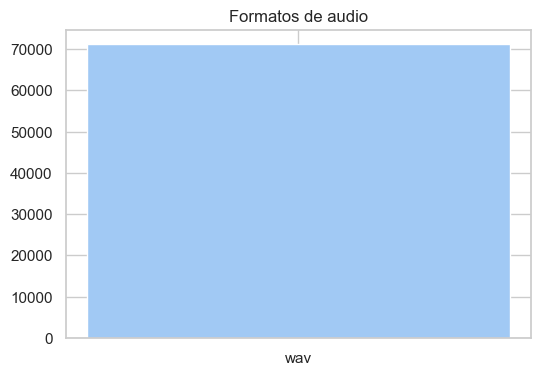

In [18]:
format_counts = eda["audio_format"].value_counts()

plt.figure(figsize=(6,4))

plt.bar(
    format_counts.index,
    format_counts.values,
    color=pastel_colors(len(format_counts))
)

plt.title("Formatos de audio")

plt.show()

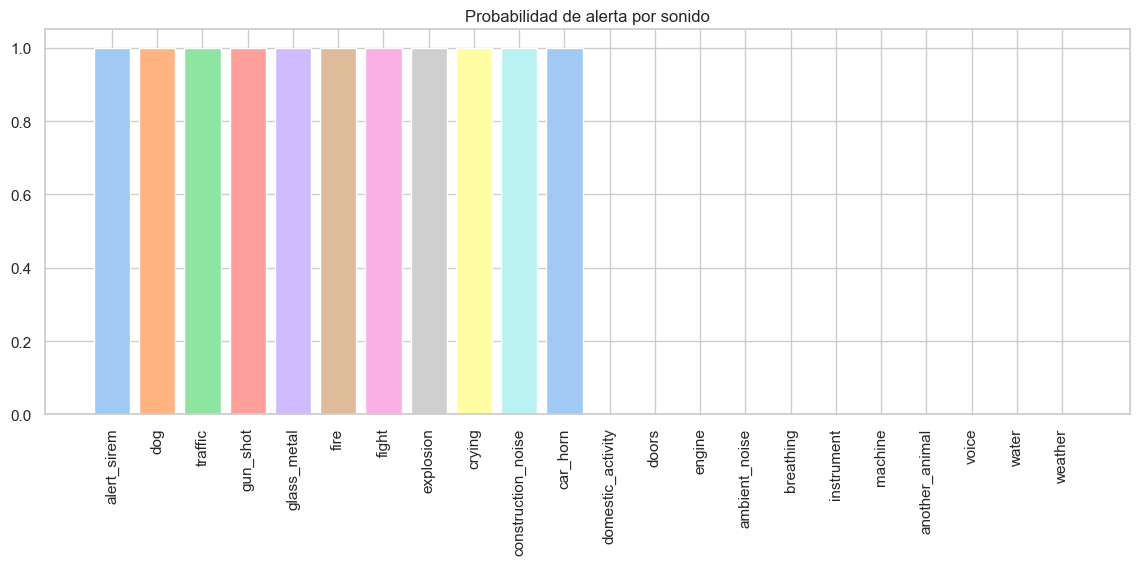

In [19]:
alert_ratio = (
    eda.groupby("human_label")["alertable"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14,5))
plt.bar(
    alert_ratio.index,
    alert_ratio.values,
    color=pastel_colors(len(alert_ratio))
)
plt.xticks(rotation=90)
plt.title("Probabilidad de alerta por sonido")
plt.show()

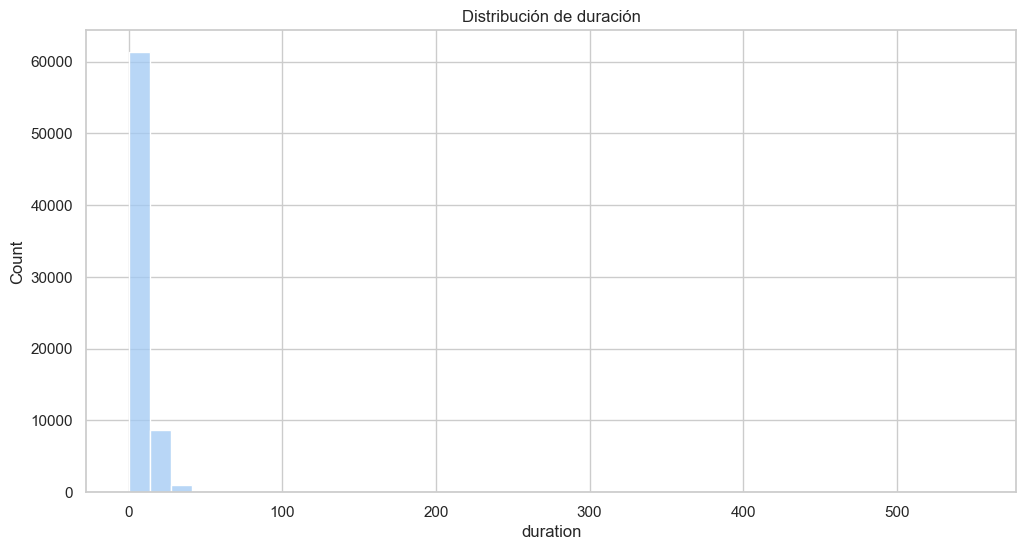

In [20]:
sns.histplot(
    eda["duration"],
    bins=40,
    color=pastel_colors(1)[0]
)
plt.title("Distribución de duración")
plt.show()

In [21]:
numeric_cols = [
    "duration",
    "sample_rate",
    "bit_depth",
    "bit_velocity",
    "size"
]

eda[numeric_cols].describe()

,duration,sample_rate,bit_depth,bit_velocity,size
count,71113.000000,71113.000000,71104.000000,7.110400e+04,71113.000000
mean,6.241172,44675.962806,16.342934,8.512647e+05,603.239016
std,7.383070,5558.819574,1.734229,5.022191e+05,736.090565
min,0.050000,8000.000000,8.000000,8.820000e+04,5.980000
25%,1.640000,44100.000000,16.000000,7.056000e+05,146.040000
50%,4.000000,44100.000000,16.000000,7.056000e+05,375.440000
75%,7.988000,44100.000000,16.000000,7.056000e+05,780.170000
max,550.249000,192000.000000,32.000000,1.228800e+07,62015.670000


C:\Users\nata1\AppData\Local\Temp\ipykernel_19248\3640297132.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


<Axes: xlabel='alertable', ylabel='duration'>

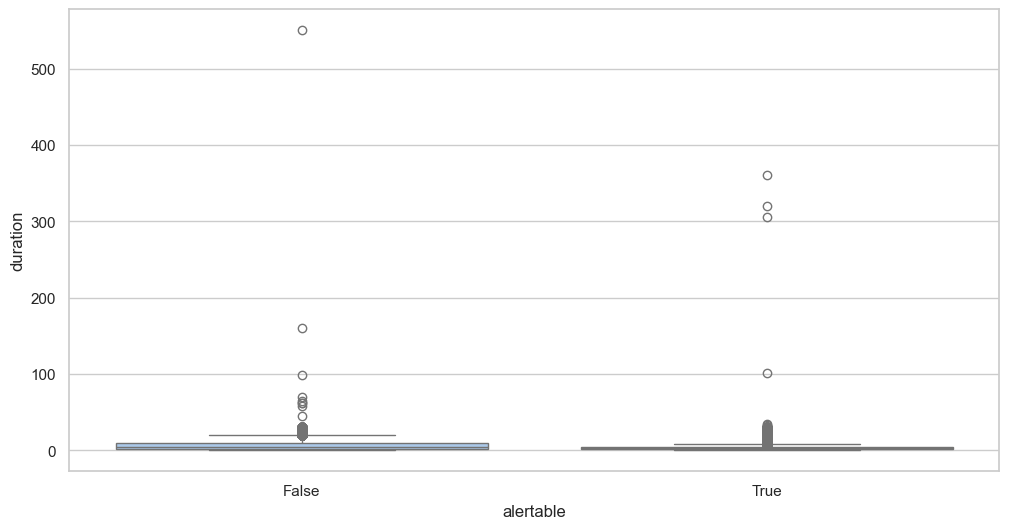

In [22]:
sns.boxplot(
    data=eda,
    x="alertable",
    y="duration",
    palette=pastel_colors(2)
)

La variabilidad en parámetros técnicos del audio confirma heterogeneidad en las condiciones de captura. Esto puede introducir ruido en el aprendizaje y sugiere la necesidad de normalización acústica previa al entrenamiento.

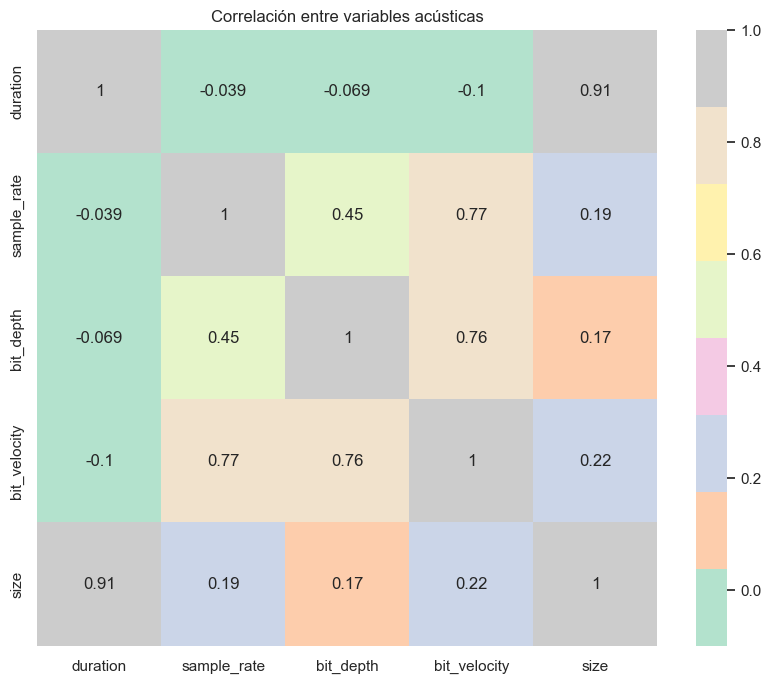

In [23]:
plt.figure(figsize=(10,8))

sns.heatmap(
    eda[numeric_cols].corr(),
    annot=True,
    cmap="Pastel2"
)

plt.title("Correlación entre variables acústicas")
plt.show()

Las correlaciones entre variables numéricas presentan baja asociación con la variable objetivo, sugiriendo que la discriminación entre clases dependerá principalmente de características espectrales del audio y no de metadatos técnicos.

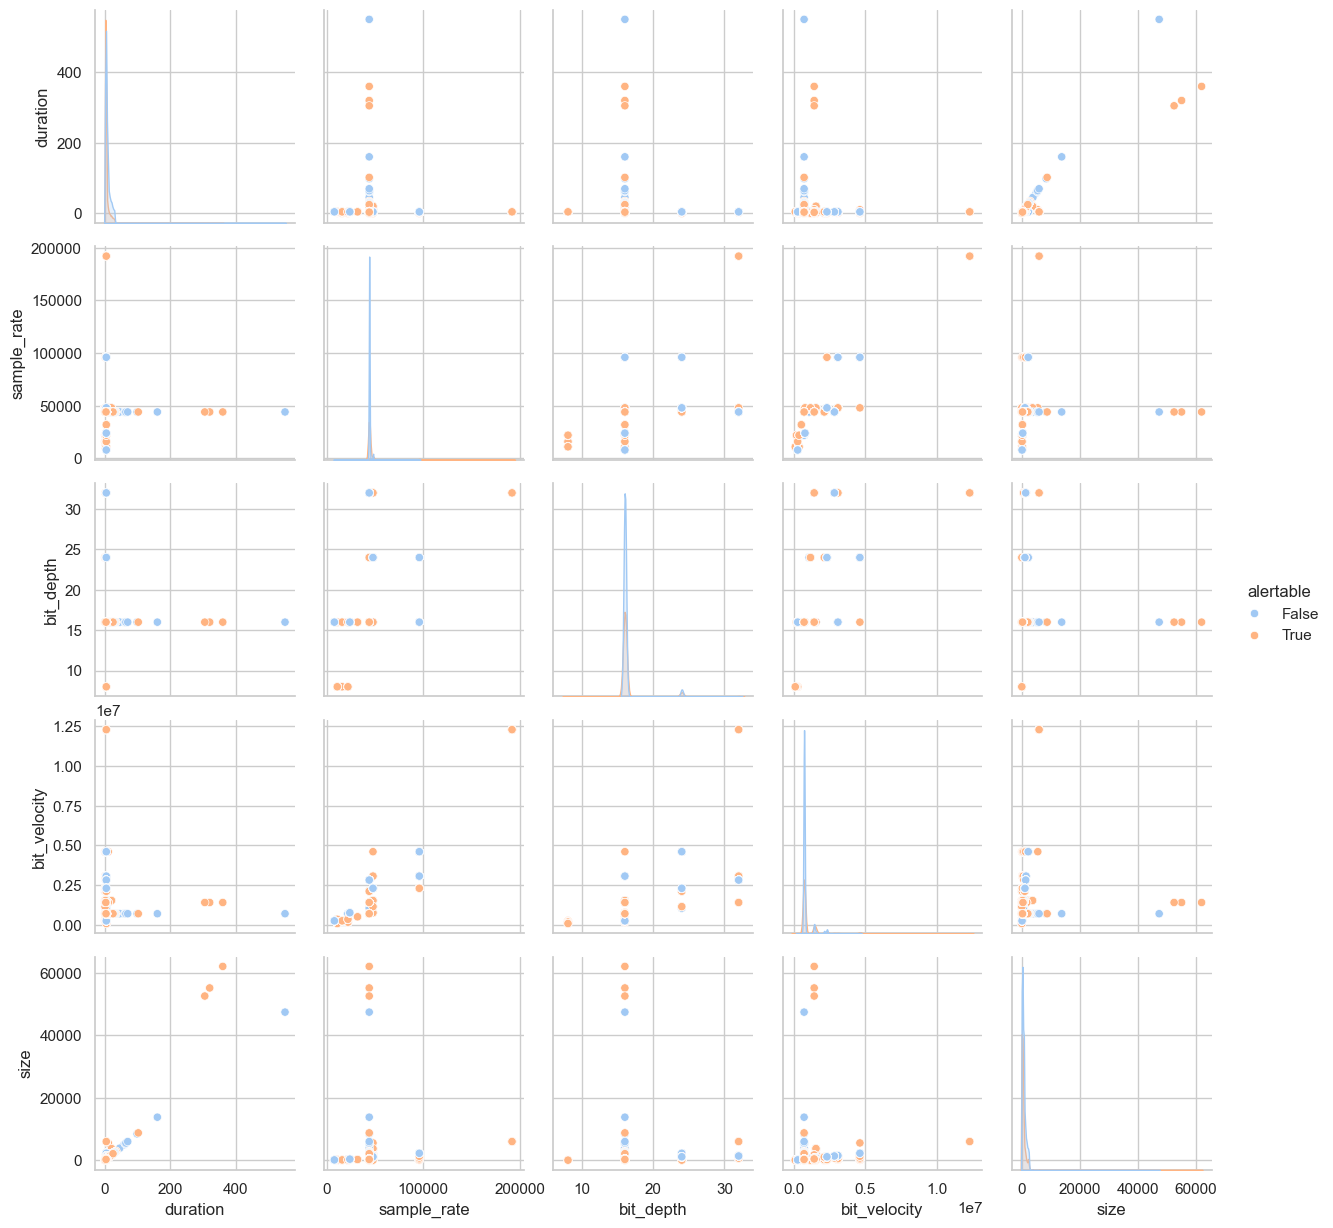

In [24]:
sns.pairplot(
    eda[numeric_cols + ["alertable"]],
    hue="alertable",
    palette="pastel"
)

El análisis multivariado mediante pairplots evidencia ausencia de separación lineal entre clases, validando la necesidad de modelos no lineales basados en representación acústica profunda.

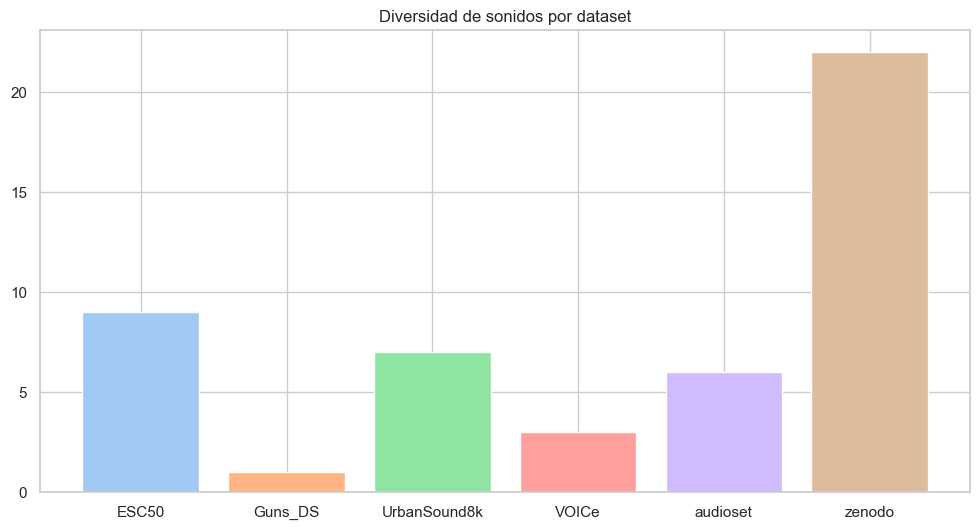

In [25]:
diversidad = eda.groupby("dataset_source")["human_label"].nunique()

plt.bar(
    diversidad.index,
    diversidad.values,
    color=pastel_colors(len(diversidad))
)

plt.title("Diversidad de sonidos por dataset")
plt.show()

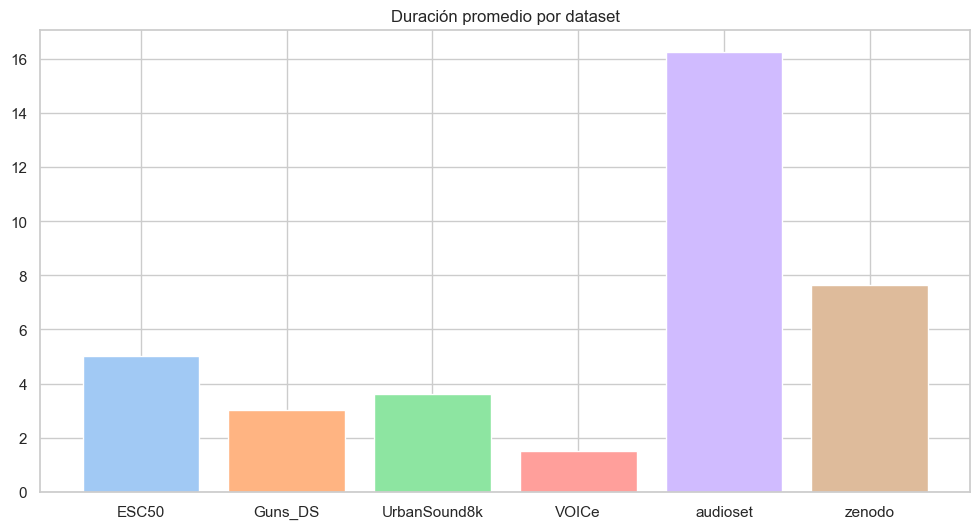

In [26]:
duracion_dataset = eda.groupby("dataset_source")["duration"].mean()

plt.bar(
    duracion_dataset.index,
    duracion_dataset.values,
    color=pastel_colors(len(duracion_dataset))
)

plt.title("Duración promedio por dataset")
plt.show()

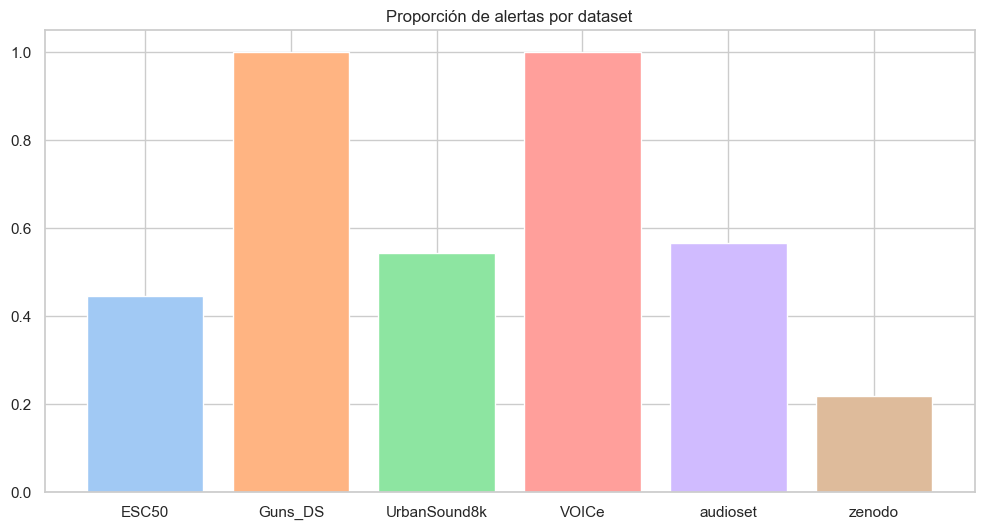

In [27]:
alert_dataset = eda.groupby("dataset_source")["alertable"].mean()

plt.bar(
    alert_dataset.index,
    alert_dataset.values,
    color=pastel_colors(len(alert_dataset))
)

plt.title("Proporción de alertas por dataset")
plt.show()

In [28]:
pd.crosstab(
    eda["env"],
    eda["alertable"],
    normalize="index"
)

alertable,False,True
env,,
exterior,0.477644,0.522356
indefinida,0.727577,0.272423
indefinido,0.000000,1.000000
interior,1.000000,0.000000


# Balanceo de clases

In [29]:
alertables = eda[eda["alertable"] == 1]
no_alertables = eda[eda["alertable"] == 0]

print("Alertables:", len(alertables))
print("No alertables:", len(no_alertables))

Alertables: 26823
No alertables: 44291


In [30]:
ratio = 2   # alertables serán el doble

### Undersampling -> clases NO alertables

In [31]:
no_alertables_under = resample(
    no_alertables,
    replace=False,
    n_samples=len(alertables),
    random_state=42
)

### Oversampling -> clases alertables

In [32]:
alertables_over = resample(
    alertables,
    replace=True,
    n_samples=len(no_alertables_under) * ratio,
    random_state=42
)

In [33]:
eda_balanced = pd.concat(
    [alertables_over, no_alertables_under]
).sample(frac=1, random_state=42)

In [34]:
eda_balanced["alertable"].value_counts(normalize=True)

alertable
True     0.666667
False    0.333333
Name: proportion, dtype: float64

<Axes: title={'center': 'Distribución original'}, xlabel='alertable'>

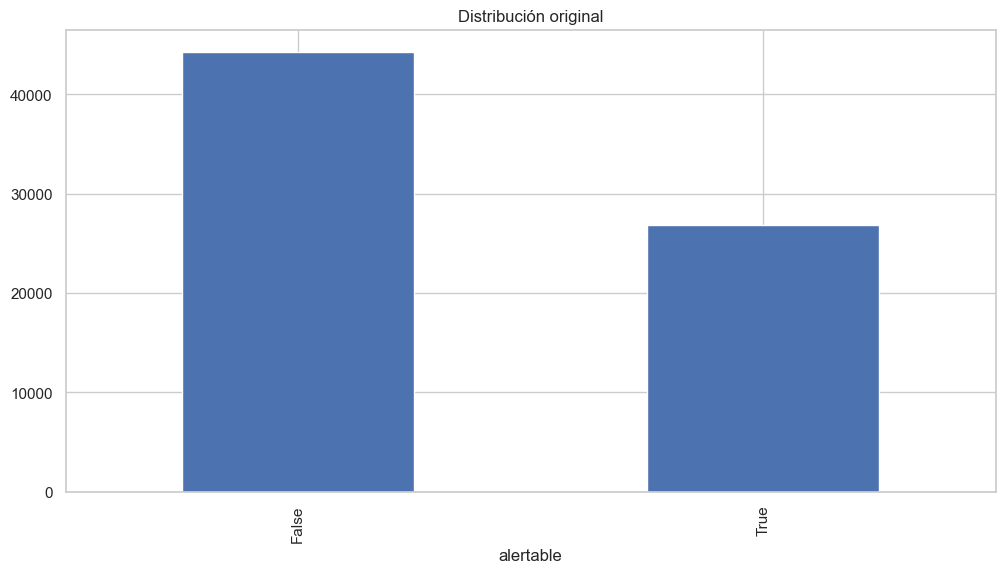

In [35]:
eda["alertable"].value_counts().plot(
    kind="bar",
    title="Distribución original"
)

<Axes: title={'center': 'Distribución balanceada (simulación)'}, xlabel='alertable'>

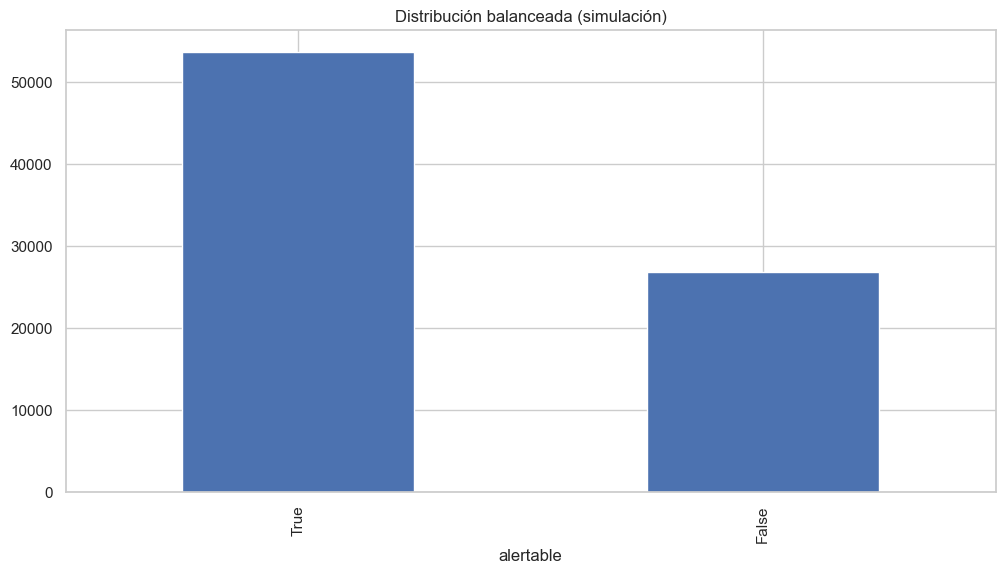

In [36]:
eda_balanced["alertable"].value_counts().plot(
    kind="bar",
    title="Distribución balanceada (simulación)"
)

In [37]:
eda_balanced["human_label"].value_counts()

human_label
glass_metal           15199
gun_shot              10432
instrument             8621
construction_noise     5971
crying                 5926
traffic                4637
domestic_activity      4265
dog                    3895
voice                  3461
ambient_noise          2979
alert_sirem            2811
another_animal         1730
fire                   1497
water                  1457
fight                  1327
weather                1186
engine                 1147
car_horn               1130
explosion               821
breathing               807
machine                 652
doors                   518
Name: count, dtype: int64

In [38]:
df = eda_balanced.copy()
label_counts = (
    df["human_label"]
    .value_counts()
    .reset_index()
)

label_counts.columns = ["label", "count"]

label_counts.head()

,label,count
0,glass_metal,15199
1,gun_shot,10432
2,instrument,8621
3,construction_noise,5971
4,crying,5926


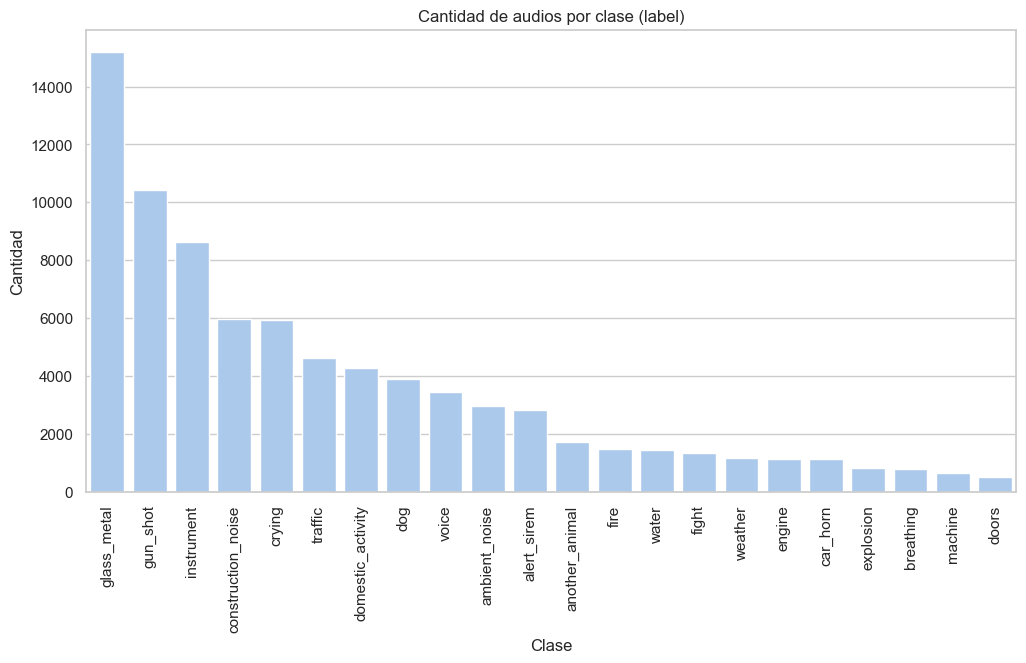

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_palette("pastel")

plt.figure(figsize=(12,6))

sns.barplot(
    data=label_counts,
    x="label",
    y="count"
)

plt.xticks(rotation=90)
plt.title("Cantidad de audios por clase (label)")
plt.xlabel("Clase")
plt.ylabel("Cantidad")

plt.show()

In [40]:
eda_balanced.to_csv("../data/raw/eda_balanced.csv", index=False)